# Conditional Neural Fields — FiLM and Hyper-RFF

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/conditioning.ipynb)

A *conditional* implicit neural field is a single network $f_\theta(x; z)$ whose behaviour at coordinate $x$ is modulated by a latent / side-information vector $z$. Instead of training one network per task, we train one network that re-uses its representation across an entire family of tasks indexed by $z$. The dividend is amortisation: a single forward pass per new task instead of a fresh optimisation run.

This idea shows up across geophysics, vision, and scientific computing:

- **Parametric PDE surrogates** — solve $\partial_t u = \mathcal{L}_\mu u$ once across a family of physical parameters $\mu$ (viscosity, diffusivity, boundary conditions). The Neural Implicit Flow architecture (Pan, Brunton, Kutz — JMLR 2023) is exactly this pattern, and it generalises across mesh resolutions because the field is queried by coordinate.
- **Few-shot signed-distance shape representation** — encode a shape collection by its latent code, then decode the SDF at any 3D coordinate. MetaSDF (Sitzmann et al. 2020) uses a hypernetwork-conditioned SIREN.
- **Conditional generative models** — class-conditional NeRFs ($\pi$-GAN, Chan et al. 2021), text-conditional implicit fields, etc., all condition the field on a latent code via FiLM.
- **Spatiotemporal regression with per-series effects** — one model fitted to many time series sharing structure but differing in a per-series latent code (e.g. one weather station's local microclimate). Conditional Bayesian neural fields lift the bayesnf workflow into this regime without rewriting the likelihood code.

Across all of these the architectural question is the same: *how does $z$ modulate the network?* This notebook walks through the two complementary answers shipped in `pyrox.nn`:

1. **FiLM-modulated SIREN** — feature-wise affine modulation $h \mapsto \gamma(z) \odot h + \beta(z)$. Tiny generators, identity at init. `pyrox.nn.AffineModulation` wired into `pyrox.nn.SIREN` via `pyrox.nn.ConditionedINR`.
2. **Hyper-RFF** — random Fourier features whose $(W, b, \log\ell)$ are *generated by a parameter network from $z$*. The conditional analogue of `pyrox.nn.RBFFourierFeatures` / `pyrox.nn.RandomKitchenSinks`.

Both expose a single `(input, z) -> y` interface so they're swappable. The Bayesian variants come for free.

## Background — three conditioning patterns

Given an inner activation $h \in \mathbb{R}^C$ and a context $z \in \mathbb{R}^K$, three primitive patterns cover the literature. They differ in *how flexibly* $z$ is allowed to enter the layer, and therefore in the parameter count of the generator that maps $z$ to its action on $h$.

| Pattern | Update | Generator size | Where it shows up |
|---|---|---|---|
| **Concat** | $y = W \, [h \,\|\, z] + b$ | $(C+K) \cdot C + C$ | DiffeqMLP, classic concat-conditioning |
| **FiLM** | $y = \gamma(z) \odot h + \beta(z)$ | $K \cdot 2C + 2C$ | $\pi$-GAN, modulated SIREN |
| **Hypernet** | $(W,b) = g(z); \; y = Wx + b$ | $K \cdot (C \cdot C_{\text{in}} + C)$ | NIF, MetaSDF |

**FiLM** (Perez et al. 2018) is the workhorse: it's parameter-efficient and identity-at-init by construction (with $\gamma = 1 + \tanh$, the layer is a no-op until trained). Concretely the generator is a single `eqx.nn.Linear` of width $2C$ that splits its output into the two halves $(\beta(z), \gamma(z))$.

**Hypernetworks** (Ha, Dai, Le — ICLR 2017) are the strict generalisation of FiLM: instead of generating the per-feature $(\gamma, \beta)$, they generate the *full target weight matrix*. They cost one matrix-multiply per layer to evaluate but can encode arbitrary $z$-dependent target functions. NIF and MetaSDF use them on top of SIREN shape-nets.

**`HyperFourierFeatures`** is the spectral-feature analogue of the hypernet: instead of generating a generic dense layer's $(W, b)$, the parameter net produces the random-Fourier-feature parameters $(W, b, \log\ell)$. The result is a *conditional spectral feature map* whose effective bandwidth (the lengthscale $\ell$) is itself a function of $z$ — perfect for parametric families that span multiple frequency scales.

### SIREN — sinusoidal representation networks

A SIREN of depth $L$ (Sitzmann et al., NeurIPS 2020) is the composition

$$
f_\theta(x) \;=\; W_L\, \phi_{L-1} \circ \cdots \circ \phi_0(x) + b_L,
\qquad
\phi_i(z) \;=\; \sin\!\bigl(\omega_i \cdot (W_i z + b_i)\bigr).
$$

The first-layer frequency $\omega_0$ is typically larger (default $30$); all hidden layers share $\omega$; the readout is linear. Compared with a ReLU MLP the only structural change is replacing $\sigma_{\mathrm{ReLU}}(z) = \max(z, 0)$ with $\sigma_{\mathrm{SIREN}}(z) = \sin(\omega z)$, which mixes frequencies up to $\omega$ in the NTK and so escapes the ReLU spectral bias.

The Sitzmann Theorem 1 init is load-bearing: weights are uniform on
$$
W_{ij}^{(\text{hidden})} \sim \mathcal{U}\!\Bigl(-\tfrac{\sqrt{c/d_{\text{in}}}}{\omega},\, \tfrac{\sqrt{c/d_{\text{in}}}}{\omega}\Bigr),
$$
which is what keeps pre-activation variance approximately unit and prevents the sine from immediately saturating. `pyrox.nn.SirenDense` and `pyrox.nn.SIREN` implement this verbatim — see the [SIREN notebook](siren_inr.ipynb) for a deep dive.

The conditional variant we build below is then

$$
f_\theta(x; z) \;=\; W_L \, \phi^{\text{FiLM}}_{L-1}(\,\cdots\, \phi^{\text{FiLM}}_0(x; z)\,;\, z) + b_L,
\qquad
\phi^{\text{FiLM}}_i(h; z) \;=\; \gamma_i(z) \odot \sin(\omega_i (W_i h + b_i)) + \beta_i(z).
$$

Each per-layer $(\gamma_i, \beta_i)$ comes from its own `AffineModulation`. `ConditionedINR` automates the wiring: it walks the inner SIREN's `layers` sequence and inserts one conditioner after every non-readout layer.

### Random Fourier features — the spectral primitive

Bochner's theorem tells us a stationary, positive-definite kernel $k(x, x')$ has a non-negative Fourier transform $p(\omega)$, and so admits a Monte-Carlo approximation

$$
k(x, x') \;\approx\; \frac{1}{M} \sum_{m=1}^{M} \cos\!\bigl(\omega_m^\top (x - x')\bigr), \qquad \omega_m \sim p(\omega).
$$

Stacking the cosine basis $\phi(x) = \sqrt{1/M} \, [\cos(\Omega^\top x), \sin(\Omega^\top x)]$ with $\Omega \in \mathbb{R}^{D \times M}$ drawn from $p(\omega)$ gives a finite-dim feature map whose inner product approximates $k$. For the RBF (Gaussian) kernel with lengthscale $\ell$,

$$
p(\omega) \;\propto\; \exp\!\Bigl(-\tfrac{\ell^2}{2}\, \|\omega\|^2\Bigr),
\quad\text{equivalently}\quad
\Omega = W / \ell, \;\; W \sim \mathcal{N}(0, I).
$$

`pyrox.nn.RBFFourierFeatures` *samples* both $W$ and $\ell$ from priors via `pyrox_sample`. `pyrox.nn.RandomKitchenSinks` adds a learnable linear head and is the de-facto SSGP-style regression backbone.

### Hyper-RFF — generating $(W, b, \log\ell)$ from $z$

The conditional version is what we want now. Instead of $W$ and $\ell$ being random/sampled, we make them **functions of the context** via a parameter net $g_\psi$:

$$
(W(z), b(z), \log\ell(z)) \;=\; \mathrm{unflatten}\bigl(g_\psi(z)\bigr),
$$

$$
\phi(x; z) \;=\; \sqrt{\tfrac{1}{M}}\, \bigl[\cos\!\bigl(W(z)^\top x / \ell(z) + b(z)\bigr),\; \sin\!\bigl(W(z)^\top x / \ell(z) + b(z)\bigr)\bigr],
$$

$$
y(x; z) \;=\; \phi(x; z)^\top \beta + b_{\text{out}}.
$$

The parameter net is a small MLP $g_\psi: \mathbb{R}^K \to \mathbb{R}^{D \cdot M + M + 1}$ — flat output that splits into the $(D \times M)$ frequency matrix, the $M$ phase offsets, and the scalar log-lengthscale. The forward computes $g_\psi(z)$ once per call; the resulting features are reused across all rows of $x$ — same efficiency trick as the shared path in `HyperLinear`. This is `pyrox.nn.HyperFourierFeatures`. Compose it with a learnable linear readout and you get `pyrox.nn.ConditionedRFFNet`, the conditional analogue of `RandomKitchenSinks`.

Because $\log\ell$ is a function of $z$, the model can *adapt its effective bandwidth per task* — a high-frequency task gets a small $\ell$, a smooth one gets a large $\ell$. That property is what makes Hyper-RFF a strong fit for parametric families with frequency variation.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from numpyro import handlers

from pyrox.nn import (
    SIREN,
    AffineModulation,
    BayesianAffineModulation,
    ConditionedINR,
    ConditionedRFFNet,
    HyperFourierFeatures,
)


KEY = jr.key(0)

/home/azureuser/localfiles/pyrox/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The synthetic problem — a parametric family of sinusoids

Each context $a \in [1, 4]$ defines a target signal

$$
u(x; a) \;=\; \sin(a x), \qquad x \in [-3, 3].
$$

We want a single conditional network that, given a fresh $a$, produces the corresponding signal. The frequency varies by $4\times$ across the family — a model that doesn't condition on $a$ collapses to the family-average ($\approx 0$). Both the FiLM-SIREN and Hyper-RFF candidates have to actively use $a$ to fit anything useful.

This is a deliberately tiny, fully reproducible toy problem: the structural lesson (per-task spectral content lives in $z$) carries directly to NIF-style PDE surrogates and to amortised-GP setups in higher dimensions.

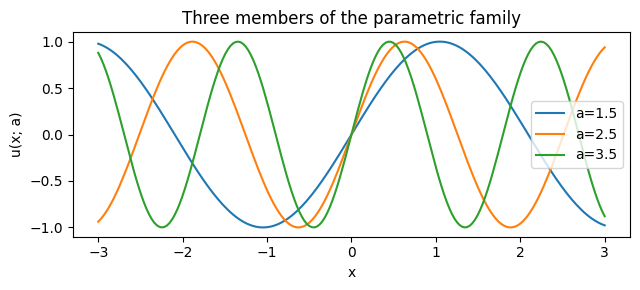

In [2]:
def sample_family(key, n=1024):
    k_a, k_x = jr.split(key)
    a = jr.uniform(k_a, (n, 1), minval=1.0, maxval=4.0)
    x = jr.uniform(k_x, (n, 1), minval=-3.0, maxval=3.0)
    y = jnp.sin(a * x)
    return x, a, y


x_train, a_train, y_train = sample_family(jr.fold_in(KEY, 0), n=1024)


fig, ax = plt.subplots(figsize=(6.5, 3))
xs = jnp.linspace(-3.0, 3.0, 200)[:, None]
for a_demo in (1.5, 2.5, 3.5):
    ax.plot(
        np.asarray(xs[:, 0]),
        np.asarray(jnp.sin(a_demo * xs[:, 0])),
        label=f"a={a_demo}",
    )
ax.set_xlabel("x")
ax.set_ylabel("u(x; a)")
ax.set_title("Three members of the parametric family")
ax.legend()
fig.tight_layout()
plt.show()

## 2. Shared training driver — cosine one-cycle with 5 restarts

Both models share the same Adam loop with a **5-cycle cosine one-cycle** schedule. Each cycle ramps the learning rate up to a peak then anneals it back to a small final value (the classic Smith 2017 super-convergence schedule); chaining 5 cycles gives the optimiser five chances to escape local minima — a poor-man's SGD-with-warm-restarts (Loshchilov & Hutter 2017). We compose five `optax.cosine_onecycle_schedule` instances via `optax.join_schedules`.

We `vmap` the model over the (x, z) batch — every row of `x_train` gets paired with the corresponding row of `a_train`.

In [3]:
COND_DIM = 4
TOTAL_STEPS = 2000


def lift_a(a):
    """Lift the scalar parameter into a (cond_dim,) latent by repetition."""
    return jnp.broadcast_to(a, (a.shape[0], COND_DIM))


z_train = lift_a(a_train)


def cosine_5cycle_schedule(total_steps, peak_lr=3e-3):
    """Five cosine one-cycle schedules concatenated.

    Each cycle ramps from ~peak_lr/25 up to peak_lr, then anneals back
    down. Five cycles = five warm restarts — analogous to SGDR.
    """
    cycle_steps = total_steps // 5
    schedules = [
        optax.cosine_onecycle_schedule(
            transition_steps=cycle_steps,
            peak_value=peak_lr,
            pct_start=0.3,
            div_factor=25.0,
            final_div_factor=1e3,
        )
        for _ in range(5)
    ]
    boundaries = [cycle_steps * (k + 1) for k in range(4)]
    return optax.join_schedules(schedules, boundaries)


def fit(model, x, z, y, *, steps, peak_lr=3e-3):
    schedule = cosine_5cycle_schedule(steps, peak_lr=peak_lr)
    opt = optax.adam(schedule)
    state = opt.init(eqx.filter(model, eqx.is_array))

    @eqx.filter_jit
    def step(m, opt_state):
        def loss(mm):
            preds = jax.vmap(mm, in_axes=(0, 0))(x, z)
            return jnp.mean((preds - y) ** 2)

        v, g = eqx.filter_value_and_grad(loss)(m)
        updates, new_state = opt.update(g, opt_state, m)
        return eqx.apply_updates(m, updates), new_state, v

    losses = []
    for _ in range(steps):
        model, state, v = step(model, state)
        losses.append(float(v))
    return model, jnp.array(losses)

### Visualising the schedule

Five cycles, each with a brief warmup → peak → cosine anneal. The dips between cycles are where the warm restart helps the optimiser jump out of shallow basins.

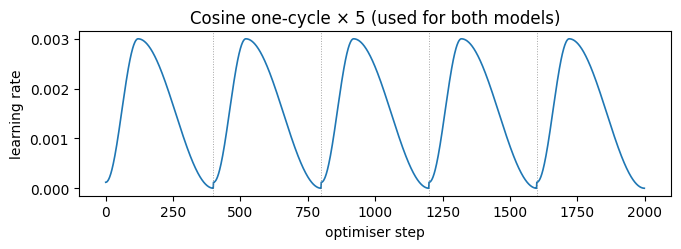

In [4]:
schedule_demo = cosine_5cycle_schedule(TOTAL_STEPS)
lr_curve = jnp.array([float(schedule_demo(s)) for s in range(TOTAL_STEPS)])

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(np.asarray(lr_curve), lw=1.2)
for k in (1, 2, 3, 4):
    ax.axvline(k * (TOTAL_STEPS // 5), color="grey", ls=":", lw=0.7, alpha=0.7)
ax.set_xlabel("optimiser step")
ax.set_ylabel("learning rate")
ax.set_title("Cosine one-cycle × 5 (used for both models)")
fig.tight_layout()
plt.show()

## 3. FiLM-modulated SIREN

`ConditionedINR(SIREN, AffineModulation)` wraps each non-readout SIREN layer with a FiLM modulator. The same SIREN backbone produces different signals depending on $z$:

$$
h_{i+1}(x; z) \;=\; \gamma_i(z) \odot \sin(\omega_i \, (W_i \, h_i + b_i)) + \beta_i(z),
$$

with each $(\gamma_i(z), \beta_i(z))$ produced by a per-layer `AffineModulation` generator
$$
(\beta_i, \mathrm{raw}_{\gamma,i}) \;=\; \mathrm{Linear}_i(z), \qquad \gamma_i \;=\; 1 + \tanh(\mathrm{raw}_{\gamma,i}),
$$
so the layer is exactly identity at init (when the generator's bias is zero and $z = 0$). Total extra params per layer: $K \cdot 2C + 2C$.

We pick `first_omega = hidden_omega = 5.0` to match the max signal frequency in our family ($a \le 4$). The default $\omega_0 = 30$ is appropriate for natural images; using it here would let the SIREN memorise individual training points and oscillate wildly between them.

In [5]:
def make_film_model(key):
    inner = SIREN.init(
        1,
        32,
        1,
        depth=4,
        key=key,
        first_omega=5.0,
        hidden_omega=5.0,
    )
    return ConditionedINR.init(
        inner,
        conditioner_cls=AffineModulation,
        cond_dim=COND_DIM,
        key=jr.fold_in(key, 1),
    )


film_model = make_film_model(jr.fold_in(KEY, 10))
film_model, film_losses = fit(film_model, x_train, z_train, y_train, steps=TOTAL_STEPS)
print(f"FiLM final train MSE: {float(film_losses[-1]):.5f}")

FiLM final train MSE: 0.00010


## 4. Hyper-RFF — parameter-net-generated Fourier features

Compared to `RBFFourierFeatures` (whose $W$, $\ell$ are NumPyro sample sites drawn from a fixed prior), `HyperFourierFeatures` makes those quantities *functions of the context*. A small MLP $g_\psi: \mathbb{R}^K \to \mathbb{R}^{DM + M + 1}$ produces the flat parameter vector that unpacks into the $(D \times M)$ frequency matrix, $M$ phase offsets, and a scalar log-lengthscale. The feature map is then standard random Fourier features:

$$
\phi(x; z) \;=\; \sqrt{\tfrac{1}{M}}\, \bigl[\cos\!\bigl(W(z)^\top x / \ell(z) + b(z)\bigr),\; \sin\!\bigl(\cdots\bigr)\bigr].
$$

A learnable linear readout converts $\phi$ to the final output:

$$
y(x; z) \;=\; \phi(x; z)^\top \beta + b_{\text{out}}.
$$

That's the entire architecture — no per-layer hyper, no init-regime ceremony. Because $\log\ell$ is itself a function of $z$, the model adapts its bandwidth per task: a high-$a$ context produces a small $\ell$, a low-$a$ context a large $\ell$. We get amortised spectral conditioning for free.

In [6]:
def make_hyperrff_model(key, n_features=32):
    pkey, _fkey, rkey = jr.split(key, 3)
    in_features = 1
    flat_size = in_features * n_features + n_features + 1
    parameter_net = eqx.nn.MLP(
        in_size=COND_DIM,
        out_size=flat_size,
        width_size=32,
        depth=2,
        key=pkey,
    )
    feat = HyperFourierFeatures.init(
        parameter_net=parameter_net,
        in_features=in_features,
        n_features=n_features,
        cond_dim=COND_DIM,
    )
    return ConditionedRFFNet.init(feat=feat, out_features=1, key=rkey)


hyperrff_model = make_hyperrff_model(jr.fold_in(KEY, 20))
hyperrff_model, hyperrff_losses = fit(
    hyperrff_model, x_train, z_train, y_train, steps=TOTAL_STEPS
)
print(f"Hyper-RFF final train MSE: {float(hyperrff_losses[-1]):.5f}")

Hyper-RFF final train MSE: 0.00005


### Side-by-side qualitative comparison

At three held-out frequencies, both models track the ground-truth signal closely. The two pieces of architecture get to the same place — the FiLM model uses identity-near-init affine modulations on a band-limited SIREN; the Hyper-RFF model adapts the lengthscale and frequency basis directly from $z$.

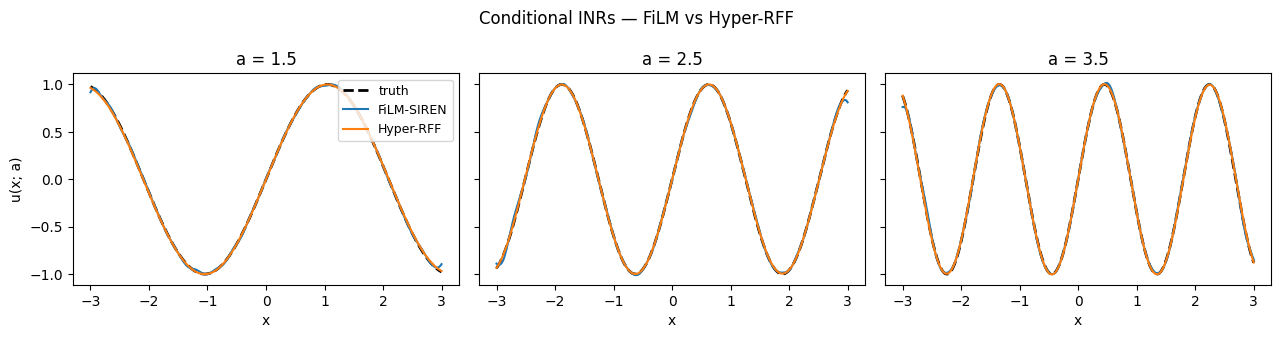

In [7]:
xs_dense = jnp.linspace(-3.0, 3.0, 400)[:, None]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, a_q in zip(axes, (1.5, 2.5, 3.5), strict=True):
    a_arr = jnp.full((xs_dense.shape[0], 1), a_q)
    z_arr = lift_a(a_arr)
    truth = jnp.sin(a_q * xs_dense[:, 0])

    film_pred = jax.vmap(film_model, in_axes=(0, 0))(xs_dense, z_arr)[:, 0]
    rff_pred = jax.vmap(hyperrff_model, in_axes=(0, 0))(xs_dense, z_arr)[:, 0]

    ax.plot(np.asarray(xs_dense[:, 0]), np.asarray(truth), "k--", lw=2.0, label="truth")
    ax.plot(
        np.asarray(xs_dense[:, 0]), np.asarray(film_pred), label="FiLM-SIREN", lw=1.5
    )
    ax.plot(np.asarray(xs_dense[:, 0]), np.asarray(rff_pred), label="Hyper-RFF", lw=1.5)
    ax.set_title(f"a = {a_q}")
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x; a)")
axes[0].legend(loc="upper right", fontsize=9)
fig.suptitle("Conditional INRs — FiLM vs Hyper-RFF")
fig.tight_layout()
plt.show()

### Loss curves

Both models reach low MSE; the cosine-restart pattern is visible in the loss spikes/dips at each cycle boundary (every 400 steps), where the LR jumps back up and briefly raises the training loss before annealing again.

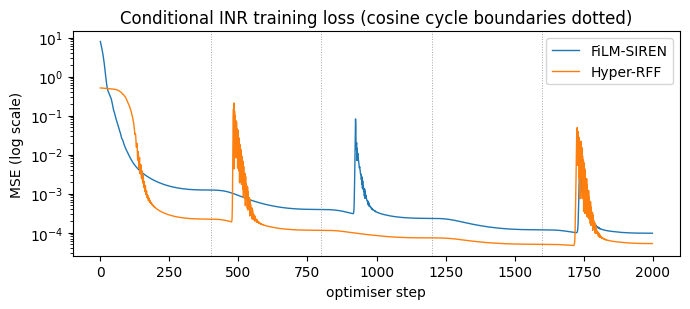

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.semilogy(np.asarray(film_losses), label="FiLM-SIREN", lw=1.0)
ax.semilogy(np.asarray(hyperrff_losses), label="Hyper-RFF", lw=1.0)
for k in (1, 2, 3, 4):
    ax.axvline(k * (TOTAL_STEPS // 5), color="grey", ls=":", lw=0.7, alpha=0.7)
ax.set_xlabel("optimiser step")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Conditional INR training loss (cosine cycle boundaries dotted)")
ax.legend()
fig.tight_layout()
plt.show()

### Held-out frequency sweep

We trained on $a \in [1, 4]$. Sweep across the training range and check both models interpolate well.

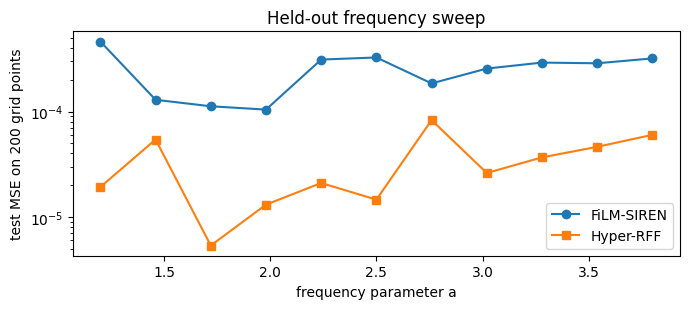

In [9]:
a_test = jnp.linspace(1.2, 3.8, 11)
errs_film, errs_rff = [], []
xs_eval = jnp.linspace(-3.0, 3.0, 200)[:, None]
for a in a_test:
    a_arr = jnp.full((xs_eval.shape[0], 1), float(a))
    z_arr = lift_a(a_arr)
    truth = jnp.sin(float(a) * xs_eval[:, 0])
    film_pred = jax.vmap(film_model, in_axes=(0, 0))(xs_eval, z_arr)[:, 0]
    rff_pred = jax.vmap(hyperrff_model, in_axes=(0, 0))(xs_eval, z_arr)[:, 0]
    errs_film.append(float(jnp.mean((film_pred - truth) ** 2)))
    errs_rff.append(float(jnp.mean((rff_pred - truth) ** 2)))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.asarray(a_test), np.asarray(errs_film), "o-", label="FiLM-SIREN")
ax.plot(np.asarray(a_test), np.asarray(errs_rff), "s-", label="Hyper-RFF")
ax.set_xlabel("frequency parameter a")
ax.set_ylabel("test MSE on 200 grid points")
ax.set_yscale("log")
ax.set_title("Held-out frequency sweep")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Bayesian conditioning — priors on the generator only

The Bayesian variant of FiLM, `BayesianAffineModulation`, places a `Normal(0, prior_std)` prior on the **generator** weights — never on the inner SIREN, never on $z$. The forward registers two NumPyro sample sites per conditioner (`gen_W`, `gen_b`), regardless of inner-network depth or width. Posterior cost scales with the *generator* size, not the target — that's the architectural advantage of Bayesian hypernetworks (NIF, MetaSDF) over directly putting priors on the target weights.

Concretely, for each non-readout SIREN layer $i$ the generator outputs $(\beta_i, \mathrm{raw}_{\gamma,i}) = W_{\text{gen},i} z + b_{\text{gen},i}$, and we sample
$$
W_{\text{gen},i} \sim \mathcal{N}(0,\, \sigma_0 I), \qquad b_{\text{gen},i} \sim \mathcal{N}(0,\, \sigma_0 I).
$$
Tracing the model under a NumPyro handler confirms exactly six sites for a depth-4 SIREN (3 non-readout layers × 2 sites each):

In [10]:
inner_for_bayes = SIREN.init(
    1,
    32,
    1,
    depth=4,
    key=jr.fold_in(KEY, 30),
    first_omega=5.0,
    hidden_omega=5.0,
)
bayes_wrapped = ConditionedINR.init(
    inner_for_bayes,
    conditioner_cls=BayesianAffineModulation,
    cond_dim=COND_DIM,
    key=jr.fold_in(KEY, 31),
)

with handlers.seed(rng_seed=0), handlers.trace() as tr:
    _ = bayes_wrapped(jnp.zeros((4, 1)), jnp.zeros((4, COND_DIM)))

site_names = sorted(tr.keys())
print(f"Number of registered sample sites: {len(site_names)}")
for name in site_names:
    print(f"  {name}")

Number of registered sample sites: 6
  BayesianAffineModulation_73cf38418cd0.gen_W
  BayesianAffineModulation_73cf38418cd0.gen_b
  BayesianAffineModulation_73cf38418f50.gen_W
  BayesianAffineModulation_73cf38418f50.gen_b
  BayesianAffineModulation_73cf385a2510.gen_W
  BayesianAffineModulation_73cf385a2510.gen_b


Sample a few prior conditioning draws and visualise the family of conditional fields they induce. Each draw gives a different mapping $a \mapsto u(\cdot; a)$; the variability across draws is the Bayesian conditioning prior at work — and shrinks as data informs the posterior under SVI / ensemble MAP.

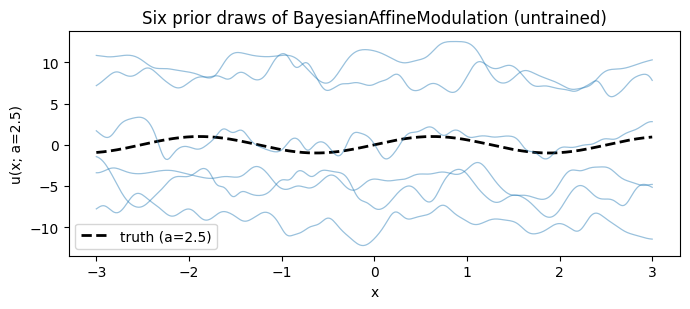

In [11]:
def predict_under_seed(seed):
    a_q = jnp.full((xs_dense.shape[0], 1), 2.5)
    z_q = lift_a(a_q)
    with handlers.seed(rng_seed=seed):
        out = jax.vmap(bayes_wrapped, in_axes=(0, 0))(xs_dense, z_q)
    return out[:, 0]


fig, ax = plt.subplots(figsize=(7, 3.2))
truth = jnp.sin(2.5 * xs_dense[:, 0])
ax.plot(
    np.asarray(xs_dense[:, 0]), np.asarray(truth), "k--", lw=2.0, label="truth (a=2.5)"
)
for s in range(6):
    pred = predict_under_seed(s)
    ax.plot(
        np.asarray(xs_dense[:, 0]), np.asarray(pred), color="C0", alpha=0.45, lw=0.9
    )
ax.set_xlabel("x")
ax.set_ylabel("u(x; a=2.5)")
ax.set_title("Six prior draws of BayesianAffineModulation (untrained)")
ax.legend()
fig.tight_layout()
plt.show()

## 6. When to pick which conditioner

- **`AffineModulation` / `FiLM`** — feature-wise modulation is enough for most "amortised" workloads (one model per timestep / per series, conditional NeRFs). Best parameter-efficiency story per layer; small, easy to wire into any inner network via `ConditionedINR`. Identity at init.
- **`HyperFourierFeatures` / `ConditionedRFFNet`** — when the parametric family changes its *spectral content* with $z$ (different frequencies, different effective bandwidth). The parameter net moves the lengthscale and frequencies in lockstep with $z$. Naturally bandwidth-controlled, no init-regime ceremony, and the conditional analogue of `RandomKitchenSinks` for SSGP-style regression.
- **`HyperLinear` / `HyperSIREN`** — strongly varying parametric families with no obvious spectral structure (PDE solutions across boundary conditions, signed-distance functions across shapes). The full-weight regime is necessary, but you must pair it with a parameter net of meaningful capacity (an MLP, not the identity).
- **`ConcatConditioner`** — the cheapest baseline; useful for fast iteration before committing to FiLM or Hyper.

All four slot into the same `(h, z) -> y` API so swapping is a one-line change, and the Bayesian variants come for free — they put priors only on the generator weights, decoupling inference cost from inner-network size.

## 7. Held-out integer-frequency interpolation

Final qualitative check: evaluate both models at the four "round" frequencies $a \in \{1.0, 2.0, 3.0, 4.0\}$. These are the endpoints and integer interior of the training range — none of them appeared exactly in the training distribution (which sampled $a$ uniformly from $[1, 4]$), so this is a clean amortised-interpolation test. A well-conditioned model should recover the truth at each of them.

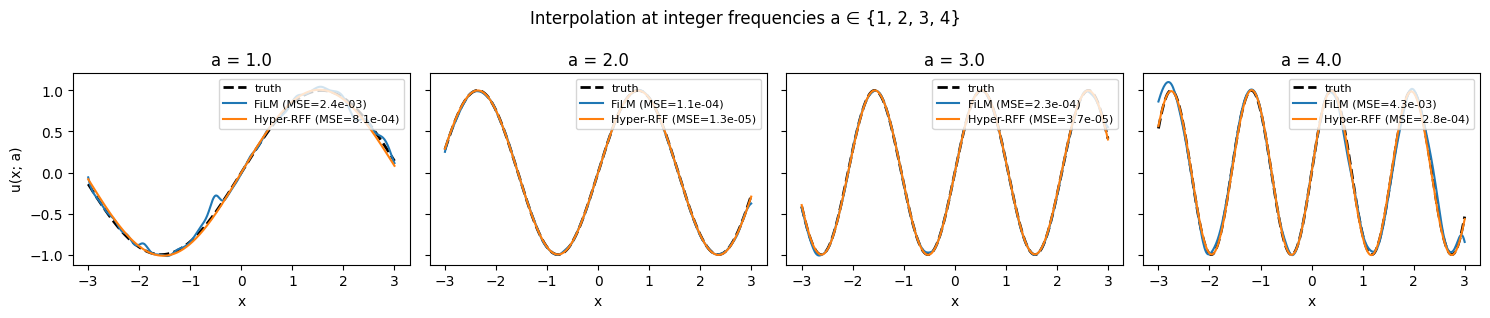

In [12]:
a_show = (1.0, 2.0, 3.0, 4.0)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, a_q in zip(axes, a_show, strict=True):
    a_arr = jnp.full((xs_dense.shape[0], 1), a_q)
    z_arr = lift_a(a_arr)
    truth = jnp.sin(a_q * xs_dense[:, 0])

    film_pred = jax.vmap(film_model, in_axes=(0, 0))(xs_dense, z_arr)[:, 0]
    rff_pred = jax.vmap(hyperrff_model, in_axes=(0, 0))(xs_dense, z_arr)[:, 0]

    film_mse = float(jnp.mean((film_pred - truth) ** 2))
    rff_mse = float(jnp.mean((rff_pred - truth) ** 2))

    ax.plot(np.asarray(xs_dense[:, 0]), np.asarray(truth), "k--", lw=2.0, label="truth")
    ax.plot(
        np.asarray(xs_dense[:, 0]),
        np.asarray(film_pred),
        label=f"FiLM (MSE={film_mse:.1e})",
        lw=1.5,
    )
    ax.plot(
        np.asarray(xs_dense[:, 0]),
        np.asarray(rff_pred),
        label=f"Hyper-RFF (MSE={rff_mse:.1e})",
        lw=1.5,
    )
    ax.set_title(f"a = {a_q}")
    ax.set_xlabel("x")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("u(x; a)")
fig.suptitle("Interpolation at integer frequencies a ∈ {1, 2, 3, 4}")
fig.tight_layout()
plt.show()

## References

- Sitzmann, Martel, Bergman, Lindell, Wetzstein — **Implicit Neural Representations with Periodic Activation Functions (SIREN)**. NeurIPS 2020. [arXiv:2006.09661](https://arxiv.org/abs/2006.09661)
- Perez, Strub, de Vries, Dumoulin, Courville — **FiLM: Visual Reasoning with Conditional Feature-wise Linear Modulation**. AAAI 2018. [arXiv:1709.07871](https://arxiv.org/abs/1709.07871)
- Rahimi, Recht — **Random Features for Large-Scale Kernel Machines**. NeurIPS 2007. [paper](https://proceedings.neurips.cc/paper/2007/hash/013a006f03dbc5392effeb8f18fda755-Abstract.html)
- Ha, Dai, Le — **HyperNetworks**. ICLR 2017. [arXiv:1609.09106](https://arxiv.org/abs/1609.09106)
- Pan, Brunton, Kutz — **Neural Implicit Flow**. JMLR 2023. [arXiv:2204.03216](https://arxiv.org/abs/2204.03216)
- Sitzmann, Chan, Tucker, Snavely, Wetzstein — **MetaSDF**. NeurIPS 2020. [arXiv:2006.09662](https://arxiv.org/abs/2006.09662)
- Smith, Topin — **Super-Convergence: Very Fast Training of Neural Networks Using Large Learning Rates**. arXiv 2017. [arXiv:1708.07120](https://arxiv.org/abs/1708.07120)
- Loshchilov, Hutter — **SGDR: Stochastic Gradient Descent with Warm Restarts**. ICLR 2017. [arXiv:1608.03983](https://arxiv.org/abs/1608.03983)